# Notebook 02b — Hybrid M1b: CRNN + Self-Attention (CNN + BiLSTM + Transformer + CTC)
### CM4609 IRP — Handwritten Prescription Medicine Name Recognition


##  Environment & configuration
Identical setup to the baseline. The MPS/CTC CPU-fallback note from Notebook 01 applies
unchanged. New hyperparameters are only those introduced by the Transformer encoder.

In [1]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"  # must precede `import torch`

import math
import random
import time
from dataclasses import dataclass
from functools import partial
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE} | torch {torch.__version__}")

Using device: mps | torch 2.12.0


In [2]:
@dataclass
class Config:
    """All experimental knobs. Data/preprocessing block is identical to the baseline so
    the comparison is controlled; the model block adds Transformer-encoder settings."""
    # --- Data (custom dataset) ---
    data_root: Path = Path("../data/pharmacy_lk")
    train_csv: str = "splits/train.csv"
    train_img_dir: str = "images"
    val_csv: str = "splits/val.csv"
    val_img_dir: str = "images"
    test_csv: str = "splits/test.csv"
    test_img_dir: str = "images"
    img_col: str = "image_filename"
    label_col: str = "medicine_name"

    # --- Preprocessing (identical to baseline 01b) ---
    img_height: int = 48
    img_width: int = 320
    pad_value: float = 1.0

    # --- Model: BiLSTM (kept from baseline) + Transformer encoder on top ---
    rnn_hidden: int = 256       # BiLSTM hidden size (matches baseline)
    rnn_layers: int = 2
    d_model: int = 256          # Transformer width; BiLSTM output is projected to this
    nhead: int = 8              # attention heads (d_model must be divisible by nhead)
    num_encoder_layers: int = 2 # fewer than pure-Transformer M1: the BiLSTM does the heavy lifting
    dim_feedforward: int = 1024
    dropout: float = 0.1

    # --- Training (same protocol as baseline) ---
    batch_size: int = 64
    epochs: int = 120
    lr: float = 3e-4            # transformers tolerate/ prefer a slightly higher LR than the
                               # CRNN here, paired with warmup; tuned in Step D if needed
    warmup_epochs: int = 8     # warmup matters MORE for transformers than for the CRNN
    weight_decay: float = 1e-4
    grad_clip: float = 5.0
    early_stop_patience: int = 20
    num_workers: int = 0        # 0 = main-process loading (required for notebook classes on macOS)
    ckpt_dir: Path = Path("../checkpoints/hybrid_m1b")

CFG = Config()
CFG.ckpt_dir.mkdir(parents=True, exist_ok=True)

## 3. Shared components (unchanged from baseline)
Vocab, dataset, preprocessing, metrics, and the seen/unseen evaluation are **identical**
to Notebook 01b. They are reproduced here so this notebook runs standalone; keeping them
byte-for-byte identical is what makes the ablation valid. (In a refactor these would live
in a shared `src/` module imported by every notebook — noted for the thesis.)

In [3]:
class Vocab:
    """char <-> index map; index 0 reserved for the CTC blank."""
    BLANK = 0

    def __init__(self, texts):
        chars = sorted(set("".join(texts)))
        self.idx2char = {i + 1: c for i, c in enumerate(chars)}
        self.char2idx = {c: i for i, c in self.idx2char.items()}

    def __len__(self):
        return len(self.idx2char) + 1

    def encode(self, text: str) -> list[int]:
        return [self.char2idx[c] for c in text]

    def decode_greedy(self, indices: list[int]) -> str:
        out, prev = [], None
        for i in indices:
            if i != prev and i != self.BLANK:
                out.append(self.idx2char[i])
            prev = i
        return "".join(out)


class WordImageDataset(Dataset):
    """Identical preprocessing to baseline: aspect-preserving resize + pad to fixed canvas."""

    def __init__(self, csv_path: Path, img_dir: Path, cfg: Config,
                 vocab: "Vocab | None" = None, augment: bool = False):
        self.df = pd.read_csv(csv_path)
        self.df = self.df.dropna(subset=[cfg.label_col])
        self.df[cfg.label_col] = self.df[cfg.label_col].astype(str).str.strip()
        self.img_dir = Path(img_dir)
        self.cfg = cfg
        self.augment = augment
        self.vocab = vocab

    def labels(self) -> list[str]:
        return self.df[self.cfg.label_col].tolist()

    def __len__(self):
        return len(self.df)

    def _load_and_resize(self, path: Path) -> Image.Image:
        img = Image.open(path).convert("L")
        w, h = img.size
        new_w = max(1, int(round(w * self.cfg.img_height / h)))
        new_w = min(new_w, self.cfg.img_width)
        img = img.resize((new_w, self.cfg.img_height), Image.BILINEAR)
        canvas = Image.new("L", (self.cfg.img_width, self.cfg.img_height), color=255)
        canvas.paste(img, (0, 0))
        return canvas

    def _augment(self, img: Image.Image) -> Image.Image:
        angle = random.uniform(-3.0, 3.0)
        return img.rotate(angle, resample=Image.BILINEAR, fillcolor=255)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self._load_and_resize(self.img_dir / str(row[self.cfg.img_col]))
        if self.augment:
            img = self._augment(img)
        x = torch.from_numpy(np.array(img, dtype=np.float32) / 255.0).unsqueeze(0)
        target = torch.tensor(self.vocab.encode(row[self.cfg.label_col]), dtype=torch.long)
        return x, target, row[self.cfg.label_col], str(row[self.cfg.img_col])


def collate(batch, pad_value: float):
    xs, targets, texts, fnames = zip(*batch)
    images = torch.stack(xs)
    target_lengths = torch.tensor([t.numel() for t in targets], dtype=torch.long)
    targets_cat = torch.cat(targets)
    return images, targets_cat, target_lengths, list(texts), list(fnames)


# ---- Metrics (identical) --------------------------------------------------------------
def edit_distance(a: str, b: str) -> int:
    if a == b:
        return 0
    if not a:
        return len(b)
    if not b:
        return len(a)
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        curr = [i]
        for j, cb in enumerate(b, 1):
            curr.append(min(prev[j] + 1, curr[j - 1] + 1, prev[j - 1] + (ca != cb)))
        prev = curr
    return prev[-1]


def corpus_metrics(preds, refs) -> dict:
    assert len(preds) == len(refs) and len(refs) > 0
    total_ed = sum(edit_distance(p, r) for p, r in zip(preds, refs))
    total_chars = sum(len(r) for r in refs)
    exact = sum(p == r for p, r in zip(preds, refs))
    return {"CER": total_ed / max(total_chars, 1), "ExactMatch": exact / len(refs),
            "WER": 1.0 - exact / len(refs), "n": len(refs)}

## 4. The M1 model: CNN backbone + Transformer encoder + CTC head

**Flow:** image → CNN (same backbone as baseline, collapses height to 1) → linear
projection to `d_model` → add positional encoding → Transformer encoder (self-attention)
→ linear CTC head → per-timestep character logits.

The CNN backbone is deliberately **identical** to the baseline's, so the only architectural
difference from M0 is "BiLSTM → Transformer encoder". That isolation is the experiment.

In [4]:
class PositionalEncoding(nn.Module):
    """Standard fixed sinusoidal positional encoding (Vaswani et al., 2017).
    Added to the feature sequence so the order-agnostic Transformer can use reading order."""

    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(1))   # (max_len, 1, d_model)

    def forward(self, x):                              # x: (T, N, d_model)
        return x + self.pe[: x.size(0)]


class CNNBiLSTMTransformerCTC(nn.Module):
    """M1b: CNN backbone -> BiLSTM -> Transformer encoder -> CTC head.

    The BiLSTM provides recurrent inductive bias (strong on small data / short words);
    the Transformer encoder adds global self-attention on top. Only the sequence-modelling
    block differs from the baseline, so M1b vs M0 isolates the effect of adding attention
    to the proven CRNN.
    """

    def __init__(self, n_classes: int, cfg: Config):
        super().__init__()

        def conv(in_c, out_c, bn=False):
            layers = [nn.Conv2d(in_c, out_c, 3, 1, 1)]
            if bn:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.ReLU(inplace=True))
            return layers

        # --- identical convolutional backbone to the baseline ---
        self.cnn = nn.Sequential(
            *conv(1, 64),    nn.MaxPool2d(2, 2),
            *conv(64, 128),  nn.MaxPool2d(2, 2),
            *conv(128, 256), *conv(256, 256),
            nn.MaxPool2d((2, 1), (2, 1)),
            *conv(256, 512, bn=True), *conv(512, 512, bn=True),
            nn.MaxPool2d((2, 1), (2, 1)),
        )
        self.collapse = nn.AdaptiveAvgPool2d((1, None))      # -> (N, 512, 1, W/4)

        # --- BiLSTM (kept from the baseline) ---
        self.rnn = nn.LSTM(input_size=512, hidden_size=cfg.rnn_hidden,
                           num_layers=cfg.rnn_layers, bidirectional=True,
                           dropout=cfg.dropout if cfg.rnn_layers > 1 else 0.0)
        rnn_out = 2 * cfg.rnn_hidden

        # --- project BiLSTM output to d_model, then a small Transformer encoder on top ---
        self.input_proj = nn.Linear(rnn_out, cfg.d_model)
        self.pos_enc = PositionalEncoding(cfg.d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=cfg.d_model, nhead=cfg.nhead,
            dim_feedforward=cfg.dim_feedforward, dropout=cfg.dropout, activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=cfg.num_encoder_layers,
                                             enable_nested_tensor=False)
        self.head = nn.Linear(cfg.d_model, n_classes)

    def forward(self, x):                 # x: (N, 1, H, W)
        f = self.cnn(x)                   # (N, 512, H', W/4)
        f = self.collapse(f)              # (N, 512, 1, W/4)
        f = f.squeeze(2).permute(2, 0, 1) # (T, N, 512) sequence-first
        f, _ = self.rnn(f)                # (T, N, 2*rnn_hidden) — recurrence first
        f = self.input_proj(f)            # (T, N, d_model)
        f = self.pos_enc(f)               # + positional encoding
        f = self.encoder(f)               # (T, N, d_model) self-attention on top
        return self.head(f)               # (T, N, n_classes) raw logits

### 4.1 Shape smoke test
Verify the encoder output is a valid CTC input sequence before training.

In [5]:
_dummy = torch.randn(2, 1, CFG.img_height, CFG.img_width)
_m = CNNBiLSTMTransformerCTC(n_classes=44, cfg=CFG)
with torch.no_grad():
    _o = _m(_dummy)
print(f"input {tuple(_dummy.shape)} -> logits {tuple(_o.shape)}  (T, N, C); expect T={CFG.img_width//4}")
assert _o.shape == (CFG.img_width // 4, 2, 44)
print(f"M1b parameters: {sum(p.numel() for p in _m.parameters())/1e6:.2f}M")
del _m, _dummy, _o

input (2, 1, 48, 320) -> logits (80, 2, 44)  (T, N, C); expect T=80
M1b parameters: 9.38M


## 5. Data loading (identical to baseline)

train=3693  val=791  test=792  classes=44


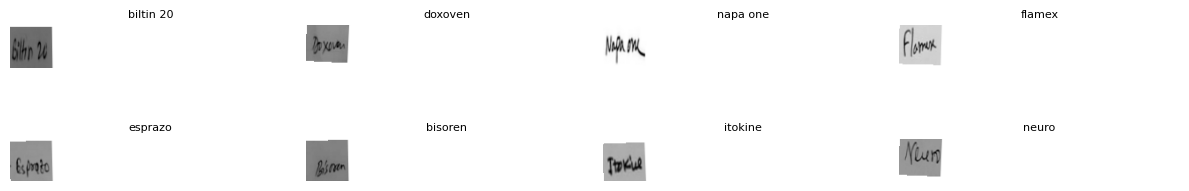

In [6]:
train_ds = WordImageDataset(CFG.data_root / CFG.train_csv, CFG.data_root / CFG.train_img_dir,
                            CFG, augment=True)
VOCAB = Vocab(train_ds.labels())
train_ds.vocab = VOCAB
val_ds = WordImageDataset(CFG.data_root / CFG.val_csv, CFG.data_root / CFG.val_img_dir,
                          CFG, vocab=VOCAB)
test_ds = WordImageDataset(CFG.data_root / CFG.test_csv, CFG.data_root / CFG.test_img_dir,
                           CFG, vocab=VOCAB)
print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}  classes={len(VOCAB)}")

_collate = partial(collate, pad_value=CFG.pad_value)
train_dl = DataLoader(train_ds, CFG.batch_size, shuffle=True,
                      num_workers=CFG.num_workers, collate_fn=_collate, drop_last=True)
val_dl   = DataLoader(val_ds, CFG.batch_size, shuffle=False,
                      num_workers=CFG.num_workers, collate_fn=_collate)
test_dl  = DataLoader(test_ds, CFG.batch_size, shuffle=False,
                      num_workers=CFG.num_workers, collate_fn=_collate)

xb, tb, tl, texts, fnames = next(iter(train_dl))
fig, axes = plt.subplots(2, 4, figsize=(12, 3))
for ax, img, txt in zip(axes.flat, xb, texts):
    ax.imshow(img.squeeze(0), cmap="gray"); ax.set_title(txt, fontsize=8); ax.axis("off")
plt.tight_layout(); plt.show()

## 6. Training (same protocol as baseline: AdamW + warmup + plateau + early stop)
Identical training/eval code to Notebook 01b — only the model object differs.

In [7]:
def greedy_decode(logits: torch.Tensor, vocab: Vocab) -> list[str]:
    idx = logits.argmax(-1).permute(1, 0)
    return [vocab.decode_greedy(seq.tolist()) for seq in idx]


@torch.no_grad()
def evaluate(model, loader, vocab):
    model.eval()
    preds, refs, files = [], [], []
    for xb, _, _, texts, fnames in loader:
        logits = model(xb.to(DEVICE))
        preds += greedy_decode(logits.cpu(), vocab)
        refs += texts
        files += fnames
    return corpus_metrics(preds, refs), preds, refs, files


def train(model, train_dl, val_dl, cfg: Config, vocab: Vocab):
    model.to(DEVICE)
    ctc = nn.CTCLoss(blank=Vocab.BLANK, zero_infinity=True)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=4)

    history, best_cer, no_improve = [], float("inf"), 0
    for epoch in range(1, cfg.epochs + 1):
        if epoch <= cfg.warmup_epochs:
            for g in opt.param_groups:
                g["lr"] = cfg.lr * epoch / cfg.warmup_epochs

        model.train()
        t0, running = time.time(), 0.0
        for xb, targets, target_lengths, _, _ in train_dl:
            xb = xb.to(DEVICE)
            logits = model(xb)
            log_probs = logits.log_softmax(2)
            T = logits.shape[0]
            input_lengths = torch.full((xb.shape[0],), T, dtype=torch.long)
            loss = ctc(log_probs.cpu(), targets, input_lengths, target_lengths)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            opt.step()
            running += loss.item() * xb.shape[0]

        train_loss = running / len(train_dl.dataset)
        val_metrics, _, _, _ = evaluate(model, val_dl, vocab)
        if epoch > cfg.warmup_epochs:
            sched.step(val_metrics["CER"])
        history.append({"epoch": epoch, "train_loss": train_loss, **val_metrics})
        print(f"epoch {epoch:3d} | loss {train_loss:.4f} | "
              f"val CER {val_metrics['CER']:.4f} | val EM {val_metrics['ExactMatch']:.4f} | "
              f"{time.time()-t0:.1f}s")

        if val_metrics["CER"] < best_cer:
            best_cer, no_improve = val_metrics["CER"], 0
            torch.save({"model": model.state_dict(), "vocab": VOCAB.idx2char,
                        "config": vars(cfg) | {"data_root": str(cfg.data_root),
                                               "ckpt_dir": str(cfg.ckpt_dir)}},
                       cfg.ckpt_dir / "best.pt")
        else:
            no_improve += 1
            if no_improve >= cfg.early_stop_patience:
                print(f"early stopping at epoch {epoch}")
                break
    return pd.DataFrame(history)


model = CNNBiLSTMTransformerCTC(n_classes=len(VOCAB), cfg=CFG)
print(f"M1b parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")
history = train(model, train_dl, val_dl, CFG, VOCAB)

M1b parameters: 9.38M
epoch   1 | loss 6.6520 | val CER 1.0000 | val EM 0.0000 | 25.7s
epoch   2 | loss 3.3232 | val CER 1.0000 | val EM 0.0000 | 19.5s
epoch   3 | loss 3.2355 | val CER 0.9835 | val EM 0.0000 | 19.5s
epoch   4 | loss 3.1641 | val CER 0.9299 | val EM 0.0000 | 19.5s
epoch   5 | loss 3.0809 | val CER 0.8916 | val EM 0.0000 | 19.5s
epoch   6 | loss 3.0029 | val CER 0.9051 | val EM 0.0000 | 19.6s
epoch   7 | loss 2.9657 | val CER 0.9107 | val EM 0.0000 | 19.5s
epoch   8 | loss 2.9533 | val CER 0.9200 | val EM 0.0000 | 19.6s
epoch   9 | loss 2.9257 | val CER 0.9514 | val EM 0.0000 | 19.5s
epoch  10 | loss 2.9002 | val CER 0.8371 | val EM 0.0000 | 19.6s
epoch  11 | loss 2.8607 | val CER 0.9036 | val EM 0.0000 | 19.6s
epoch  12 | loss 2.8419 | val CER 0.8580 | val EM 0.0177 | 19.6s
epoch  13 | loss 2.8180 | val CER 0.8667 | val EM 0.0278 | 19.5s
epoch  14 | loss 2.7919 | val CER 0.8851 | val EM 0.0000 | 19.5s
epoch  15 | loss 2.7835 | val CER 0.8871 | val EM 0.0000 | 19.5s
epo

## 7. Learning curves

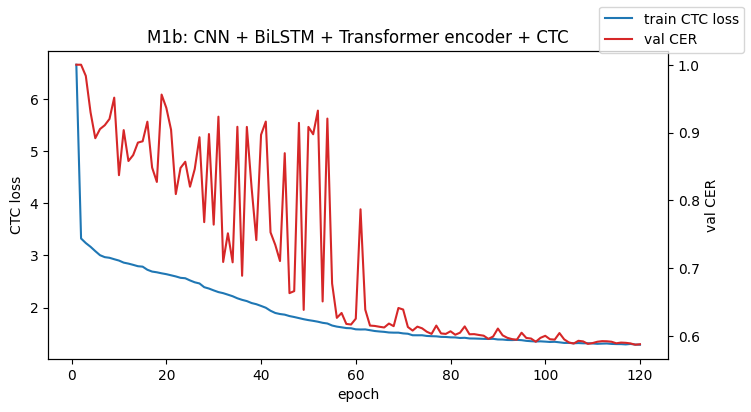

In [8]:
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(history["epoch"], history["train_loss"], label="train CTC loss")
ax1.set_xlabel("epoch"); ax1.set_ylabel("CTC loss")
ax2 = ax1.twinx()
ax2.plot(history["epoch"], history["CER"], color="tab:red", label="val CER")
ax2.set_ylabel("val CER")
fig.legend(loc="upper right"); plt.title("M1b: CNN + BiLSTM + Transformer encoder + CTC"); plt.show()

## 8. Test evaluation + seen/unseen breakdown (same as baseline)
Reports the SAME metrics on the SAME splits as Notebook 01b, so M1 vs M0 is directly
comparable. The seen/unseen split is the key comparison: does self-attention help the
open-vocabulary (unseen) case, where the baseline scored ~0?

In [9]:
ckpt = torch.load(CFG.ckpt_dir / "best.pt", map_location="cpu")
model.load_state_dict(ckpt["model"]); model.to(DEVICE)

test_metrics, test_preds, test_refs, test_files = evaluate(model, test_dl, VOCAB)
print("M1b — test (overall):",
      {k: round(v, 4) if isinstance(v, float) else v for k, v in test_metrics.items()})

test_df = pd.read_csv(CFG.data_root / CFG.test_csv)
seen_map = dict(zip(test_df[CFG.img_col].astype(str), test_df["seen_in_train"]))
groups = {"seen": ([], []), "unseen": ([], [])}
for pred, ref, fn in zip(test_preds, test_refs, test_files):
    key = "seen" if seen_map.get(fn, False) else "unseen"
    groups[key][0].append(pred); groups[key][1].append(ref)

print("\nbreakdown by vocabulary:")
for key, (P, R) in groups.items():
    if R:
        gm = corpus_metrics(P, R)
        print(f"  {key:6s} (n={gm['n']:3d}): CER {gm['CER']:.4f} | ExactMatch {gm['ExactMatch']:.4f}")

errors = [(r, p, edit_distance(p, r)) for p, r in zip(test_preds, test_refs) if p != r]
errors.sort(key=lambda e: -e[2])
err_df = pd.DataFrame(errors, columns=["reference", "prediction", "edit_distance"])
err_df.to_csv(CFG.ckpt_dir / "m1b_errors.csv", index=False)
print(f"\n{len(errors)} errors / {len(test_refs)} samples. Worst 15:")
err_df.head(15)

M1b — test (overall): {'CER': 0.5969, 'ExactMatch': 0.1402, 'WER': 0.8598, 'n': 792}

breakdown by vocabulary:
  seen   (n=613): CER 0.5318 | ExactMatch 0.1811
  unseen (n=179): CER 0.7921 | ExactMatch 0.0000

681 errors / 792 samples. Worst 15:


,reference,prediction,edit_distance
0,spironolactone 25mg,amg,16
1,terbinaforce 250mg,r eg,15
2,zerodol cr 200mg,a nm,14
3,domperidone 10mg,canen,14
4,augmentin 625mg,omg,13
5,tab.aristovif-3,delbren-d,13
6,rosuvastatin 10mg,e 0mg,13
7,augmentin 625mg,cal0mg,13
8,augmentin 625mg,ae,13
9,periodontitis,malcil,12


## 9. Record for the ablation table

Add this row to your results spreadsheet next to the baseline:

| Model | Overall CER | Overall EM | Seen EM | Unseen EM | Params | s/epoch |
|-------|-------------|------------|---------|-----------|--------|---------|
| M0 CRNN baseline | 0.409 | 0.274 | 0.352 | 0.006 | 7.68M | ~18 |
| M1 CNN+Transformer+CTC (data-hungry, worse) | 0.474 | 0.222 | 0.287 | 0.000 | 7.80M | ~18 |
| **M1b CNN+BiLSTM+Transformer+CTC** | ? | ? | ? | ? | ? | ? |

**What to look for when you read M1's result:**
- If M1b's overall CER < 0.409, adding attention to the CRNN helped — note by how much.
- The interesting question is the **unseen** column. CTC with no decoder/lexicon still
  cannot invent unseen spellings, so do NOT expect unseen EM to jump much yet — that is
  what M2 (attention decoder) and especially M3 (lexicon) are for. A flat unseen column
  here is an expected, reportable finding, not a failure.
- If M1b ≈ M0, that is ALSO a valid result: it would suggest the bottleneck on this
  dataset is the open-vocabulary problem, not the sequence model — strengthening the case
  for the lexicon component. Either outcome advances the thesis argument.

**Next:** M2 adds a joint CTC–attention decoder on top of this same encoder.